# Analysis of single-cell RNA-seq data from sympathetic neurons

David Oliveira, 2025

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import os
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib.cm as mpl_cm
from cycler import cycler

sc.settings.set_figure_params(dpi=150, facecolor='white')
sc.settings.n_jobs = 30

# Palette
from matplotlib import pyplot as plt, cm as mpl_cm
from cycler import cycler
palette=cycler(color=mpl_cm.tab20.colors)

/home/davi/intelpython3/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
wd = '/home/davi/Bioinfo/ObesityLab/SympGanglia/SympAtlas_manuscript/data/'

In [3]:
# Human stellate
# adata = sc.read_h5ad(wd + 'Public_datasets/Human/Stellate/HumanStellate_analysed.h5ad')
adata = sc.read_h5ad('Old_SympAtlas_Neurons_Samson_Ji.h5ad')
adata

AnnData object with n_obs × n_vars = 35333 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Furlan_NatNeuro16_annotations', 'Furlan_NatNeuro16_CellArea', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Study', 'Ganglion', 'internal_batch', 'batch', 'Sharma_eLife23_annotations', 'percent.mt', 'tissue', 'nCount_SCT', 'nFeature_SCT', 'RNA_snn_res.0.8', 'seurat_clusters', 'celltype', 'MappsThomsen_CellRep22_annotations', 'Ziegler_Science23_internal_group', 'ori_sample', 'run', 'percent.rps', 'integrated_snn_res.0.5', 'integrated_snn_res.0.2', 'cell_type', 'condition', 'Sarker_Nature25_annotations', 'Sarker_Nature25_internal_group', 'study', 'Species', 'prob_doublet', 'Davis_Hypertension20_internal_Davis_Hypertension20_internal_group', 'Davis_Hypertension20_internal_group', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 

In [85]:
adata.write_h5ad('Old_SympAtlas_Neurons_Samson_Ji.h5ad')

In [4]:
adata = adata[adata.obs['Species'] == 'Mouse', :].copy()
adata

AnnData object with n_obs × n_vars = 35333 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Furlan_NatNeuro16_annotations', 'Furlan_NatNeuro16_CellArea', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Study', 'Ganglion', 'internal_batch', 'batch', 'Sharma_eLife23_annotations', 'percent.mt', 'tissue', 'nCount_SCT', 'nFeature_SCT', 'RNA_snn_res.0.8', 'seurat_clusters', 'celltype', 'MappsThomsen_CellRep22_annotations', 'Ziegler_Science23_internal_group', 'ori_sample', 'run', 'percent.rps', 'integrated_snn_res.0.5', 'integrated_snn_res.0.2', 'cell_type', 'condition', 'Sarker_Nature25_annotations', 'Sarker_Nature25_internal_group', 'study', 'Species', 'prob_doublet', 'Davis_Hypertension20_internal_Davis_Hypertension20_internal_group', 'Davis_Hypertension20_internal_group', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 

In [95]:
adata.obs['Study'].value_counts()

Study
Sivori_eLife24            22032
Zeisel_Cell18              3341
Ziegler_Science23          3072
MappsThomsen_CellRep22     2353
Sharma_eLife23             1142
Ge_JVisExp22               1107
Wang_Nature24              1054
Lee_Protocols22             641
Sarker_bioRxiv24            354
Furlan_NatNeuro16           237
Name: count, dtype: int64

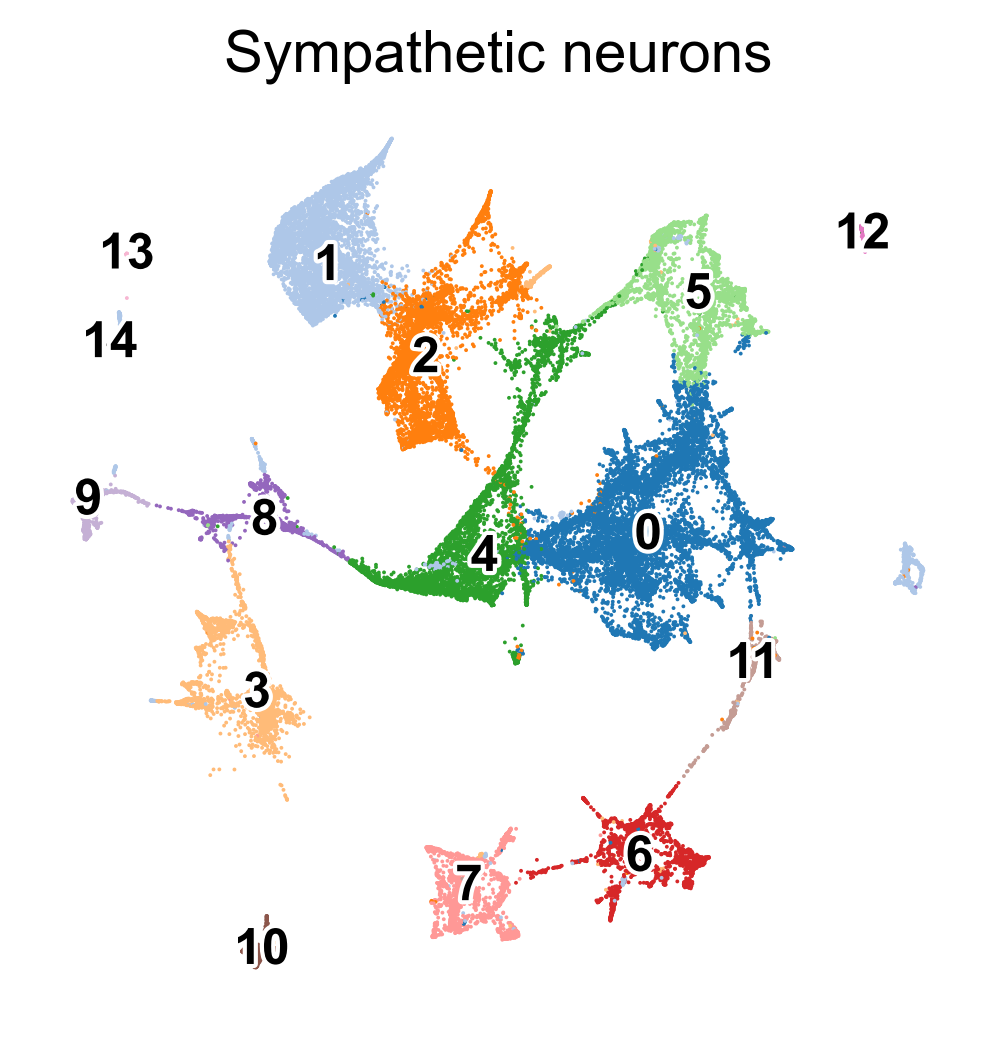

In [96]:
sc.pl.embedding(adata, basis='topoPaCMAP', color=['Leiden on topological graph (low-res)'],
                 legend_loc='on data', legend_fontsize=12, legend_fontoutline=2, title='Sympathetic neurons',
                   frameon=False)

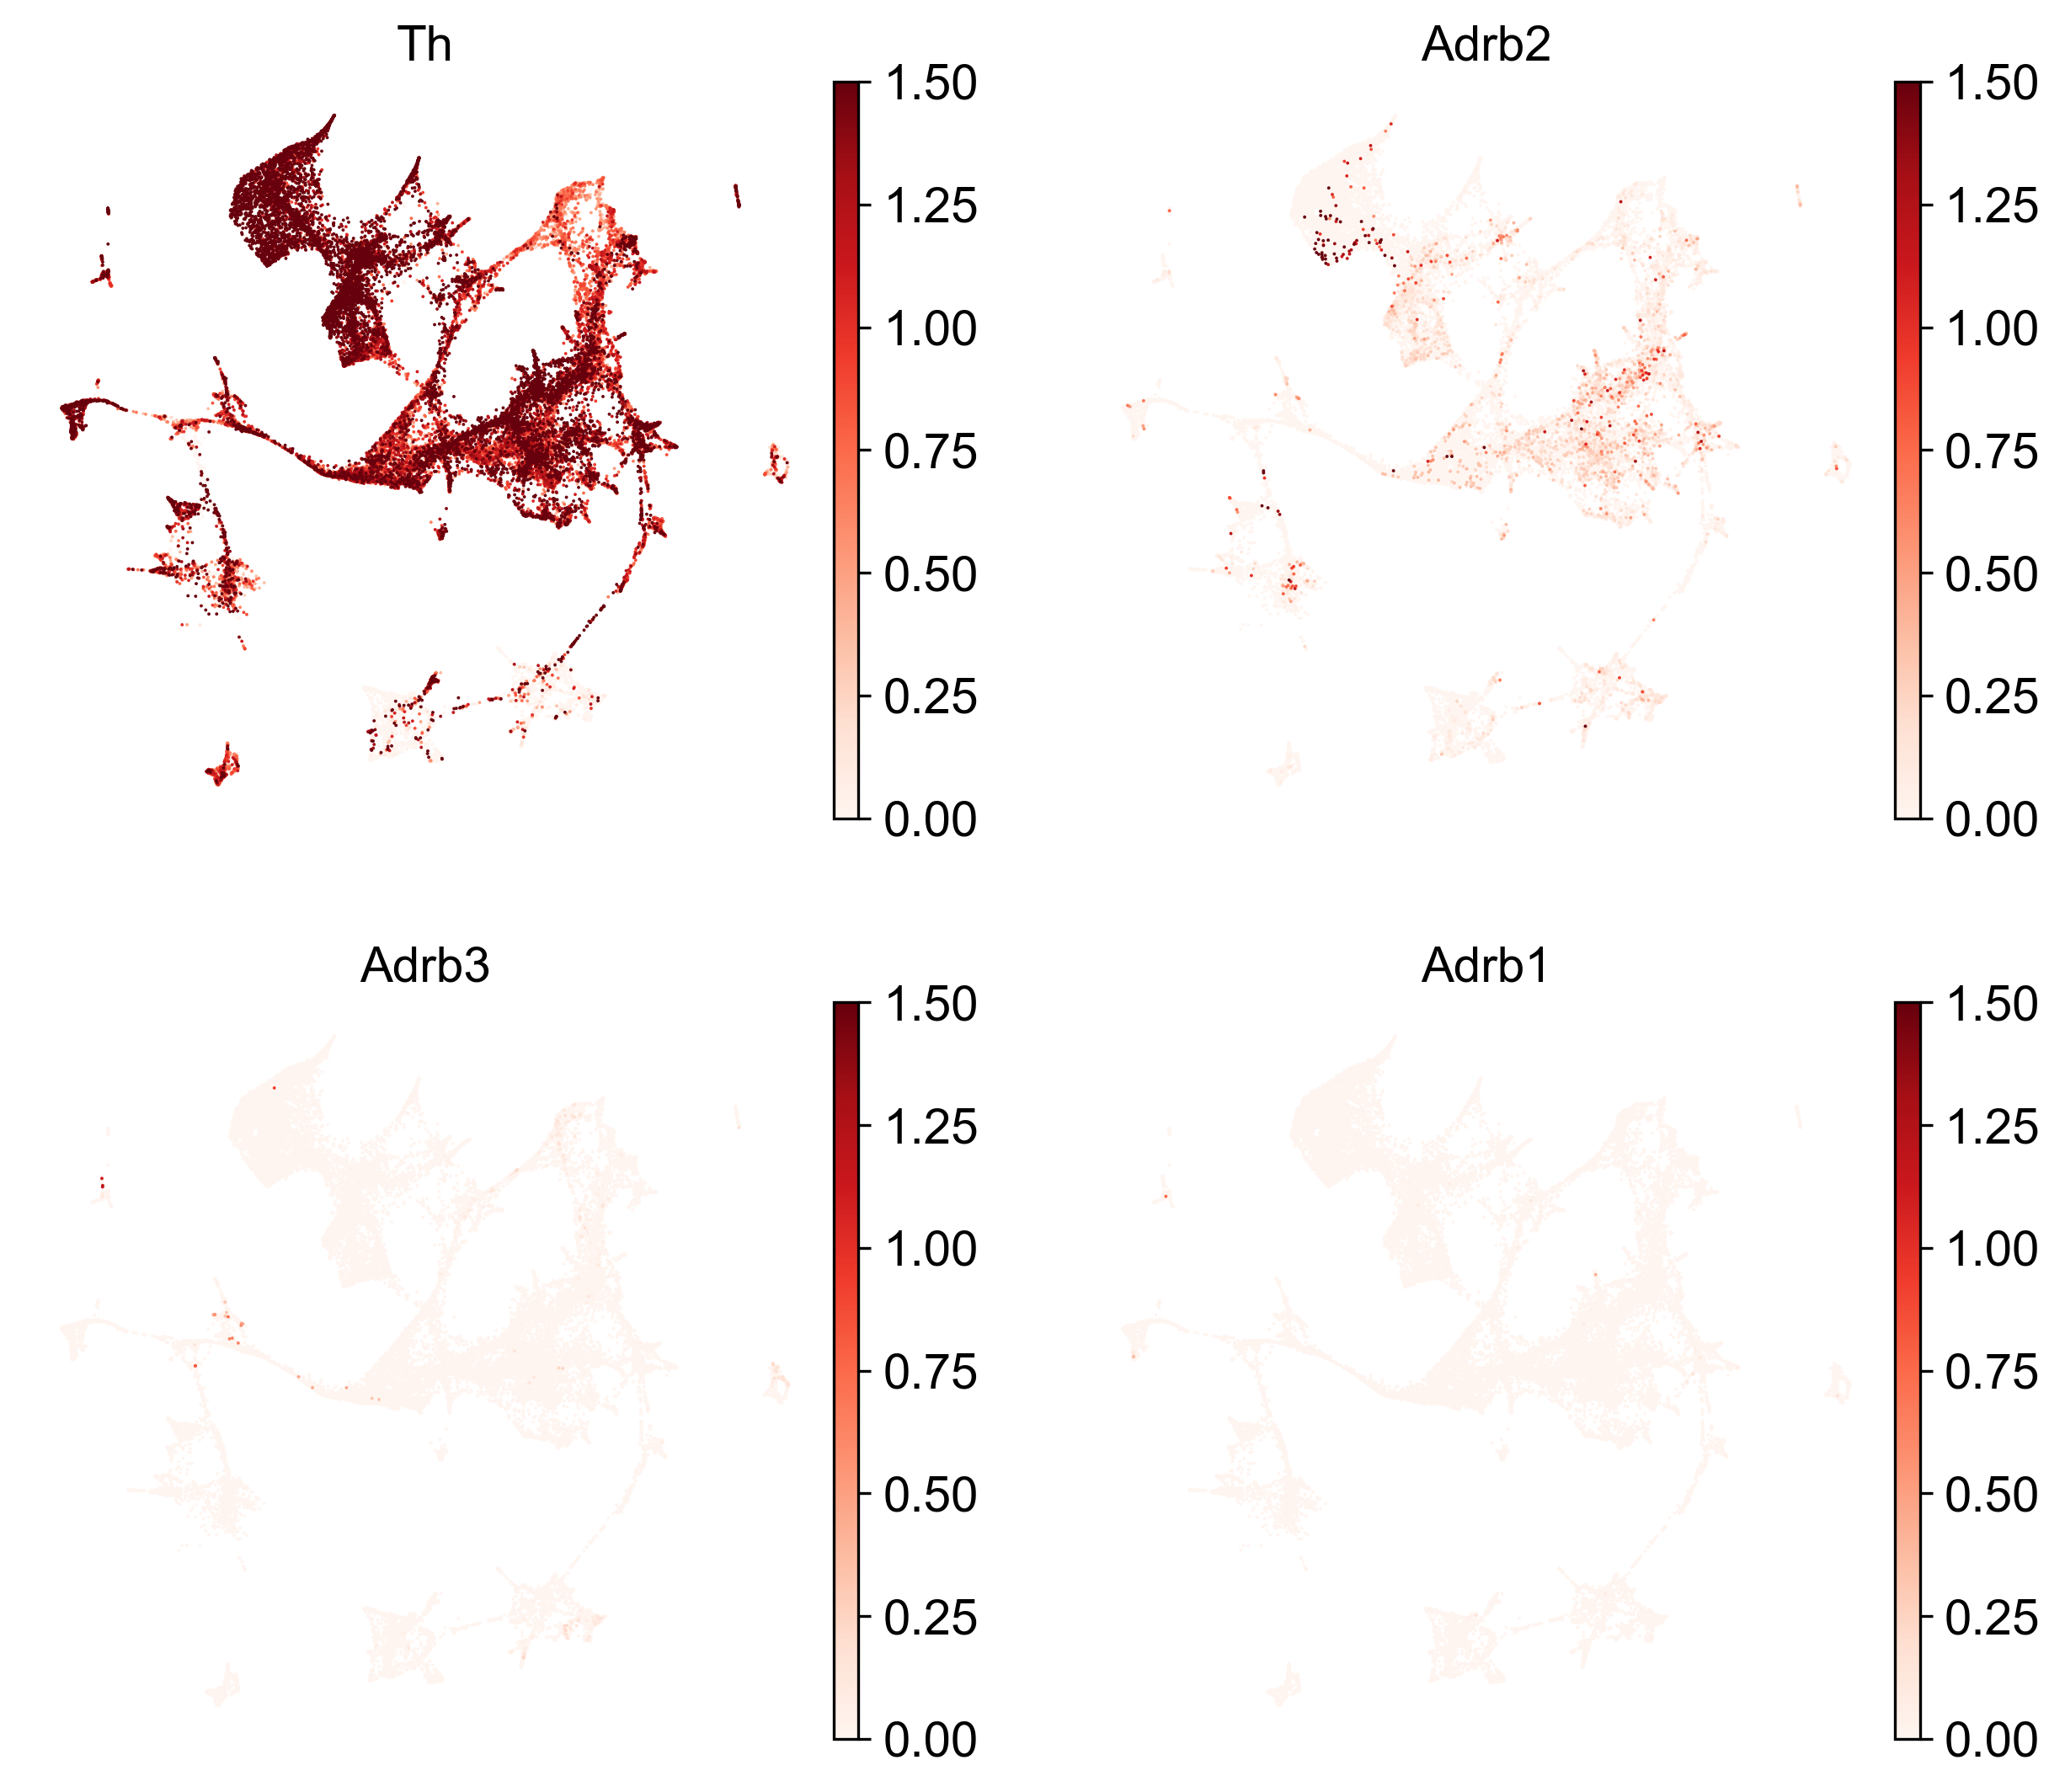

In [47]:
sc.pl.embedding(adata, basis='topoPaCMAP', color=['Th', 'Adrb2', 'Adrb3', 'Adrb1'],
                 legend_loc='on data', legend_fontsize=12, legend_fontoutline=2, cmap='Reds', vmin=0, vmax=1.5, ncols=2,
                   frameon=False)

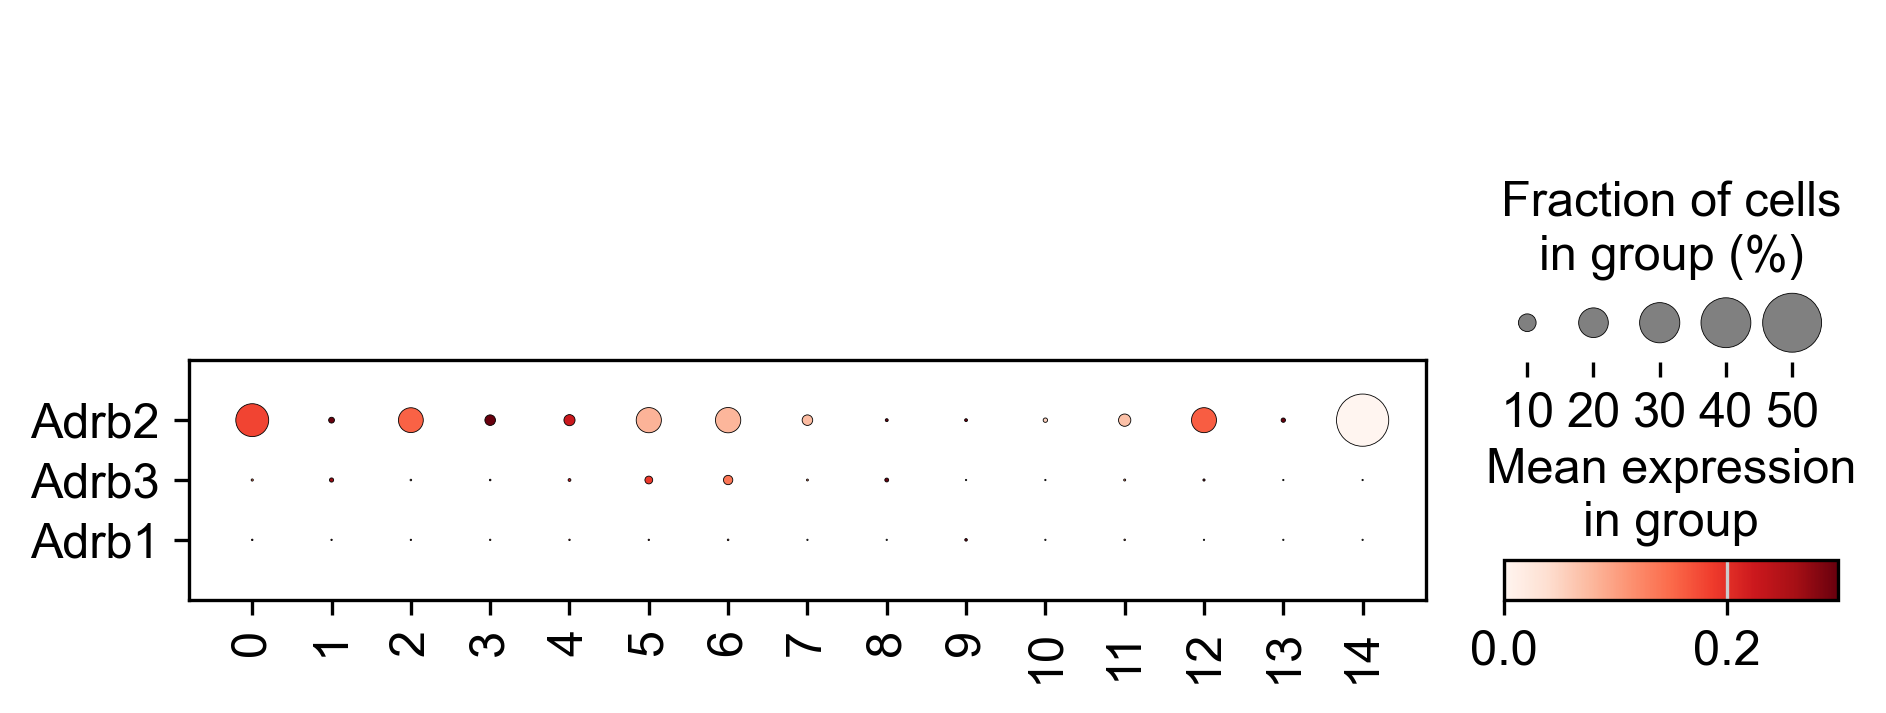

In [43]:
sc.pl.dotplot(adata, var_names=['Adrb2', 'Adrb3', 'Adrb1'], groupby='Leiden on topological graph (low-res)', standard_scale='var', swap_axes=True, vmax=0.3,
              mean_only_expressed=True, smallest_dot=0.1)

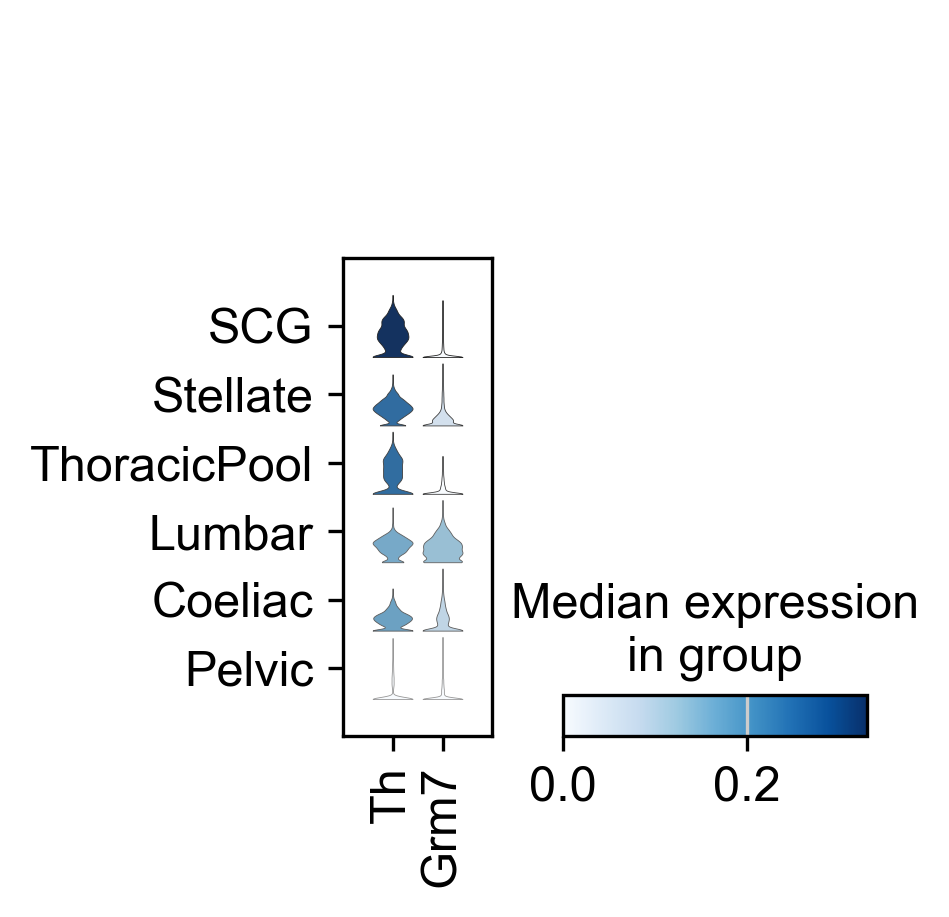

In [56]:
adata.obs['Ganglion'] = pd.Categorical(adata.obs['Ganglion'], categories=['SCG', 'Stellate', 'ThoracicPool', 'Lumbar', 'Coeliac', 'Pelvic'], ordered=True)
sc.pl.stacked_violin(adata, var_names=['Th','Grm7'], groupby='Ganglion', standard_scale='var', swap_axes=False, use_raw=True, scale='area')

Suspicious clusters:
- SatGlia markers: 34, 41,42,30
- Immune markers: 28

In [6]:
adata = adata.raw.to_adata()
adata.raw = adata

# Compare Th+/Adrb2+ cells to Th+/Adrb2- cells

In [25]:
import re
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.sparse as sps

gene1 = "Th"
gene2 = "Adrb2"
thr1 = 0.0
thr2 = 0.0
use_raw = True
key = f"{gene1}_pos_{gene2}_de"

# Exclude genes starting with "Gm...","RP", "Rpl", "Rps", "Rik", "mt-", "Hb", "HbA", "HbB", "HbP", "HbD", "HbQ", "HbZ"
exclude_gene_regex = r"^(Gm\d+)"
n_label = 12

adata_expr = adata.raw.to_adata() if use_raw else adata
X_expr = adata_expr.X
var_names = adata_expr.var_names

i1 = var_names.get_loc(gene1)
i2 = var_names.get_loc(gene2)

x1 = X_expr[:, i1]
x2 = X_expr[:, i2]
if sps.issparse(x1):
    x1 = x1.toarray().ravel()
else:
    x1 = np.asarray(x1).ravel()
if sps.issparse(x2):
    x2 = x2.toarray().ravel()
else:
    x2 = np.asarray(x2).ravel()

m_th_pos = x1 > thr1
m_adrb2_pos = x2 > thr2
mask = m_th_pos

adata_sub = adata[mask].copy()
x2_sub = x2[mask]

group_pos = f"{gene1}+/{gene2}+"
group_neg = f"{gene1}+/{gene2}-"

adata_sub.obs["comparison"] = pd.Categorical(
    np.where(x2_sub > thr2, group_pos, group_neg),
    categories=[group_pos, group_neg],
)

sc.tl.rank_genes_groups(
    adata_sub,
    groupby="comparison",
    groups=[group_pos],
    reference=group_neg,
    method="wilcoxon",
    use_raw=use_raw,
    pts=True,
    key_added=key,
)

df = sc.get.rank_genes_groups_df(adata_sub, key=key, group=group_pos).copy()
df["logfoldchanges"] = pd.to_numeric(df["logfoldchanges"], errors="coerce")
df["pvals_adj"] = pd.to_numeric(df["pvals_adj"], errors="coerce")

df = df[np.isfinite(df["logfoldchanges"]) & np.isfinite(df["pvals_adj"])].copy()
df = df[df["pvals_adj"] < 1.0].copy()
df = df[~df["names"].str.contains(exclude_gene_regex, regex=True, na=False)].copy()
df["neglog10_padj"] = -np.log10(df["pvals_adj"].clip(lower=1e-300))

top_up = df[df["logfoldchanges"] > 0].nlargest(n_label, "logfoldchanges")
top_dn = df[df["logfoldchanges"] < 0].nsmallest(n_label, "logfoldchanges")
lab = pd.concat([top_up, top_dn], axis=0).drop_duplicates("names")


/tmp/ipykernel_2498327/2985036265.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df["names"].str.contains(exclude_gene_regex, regex=True, na=False)].copy()


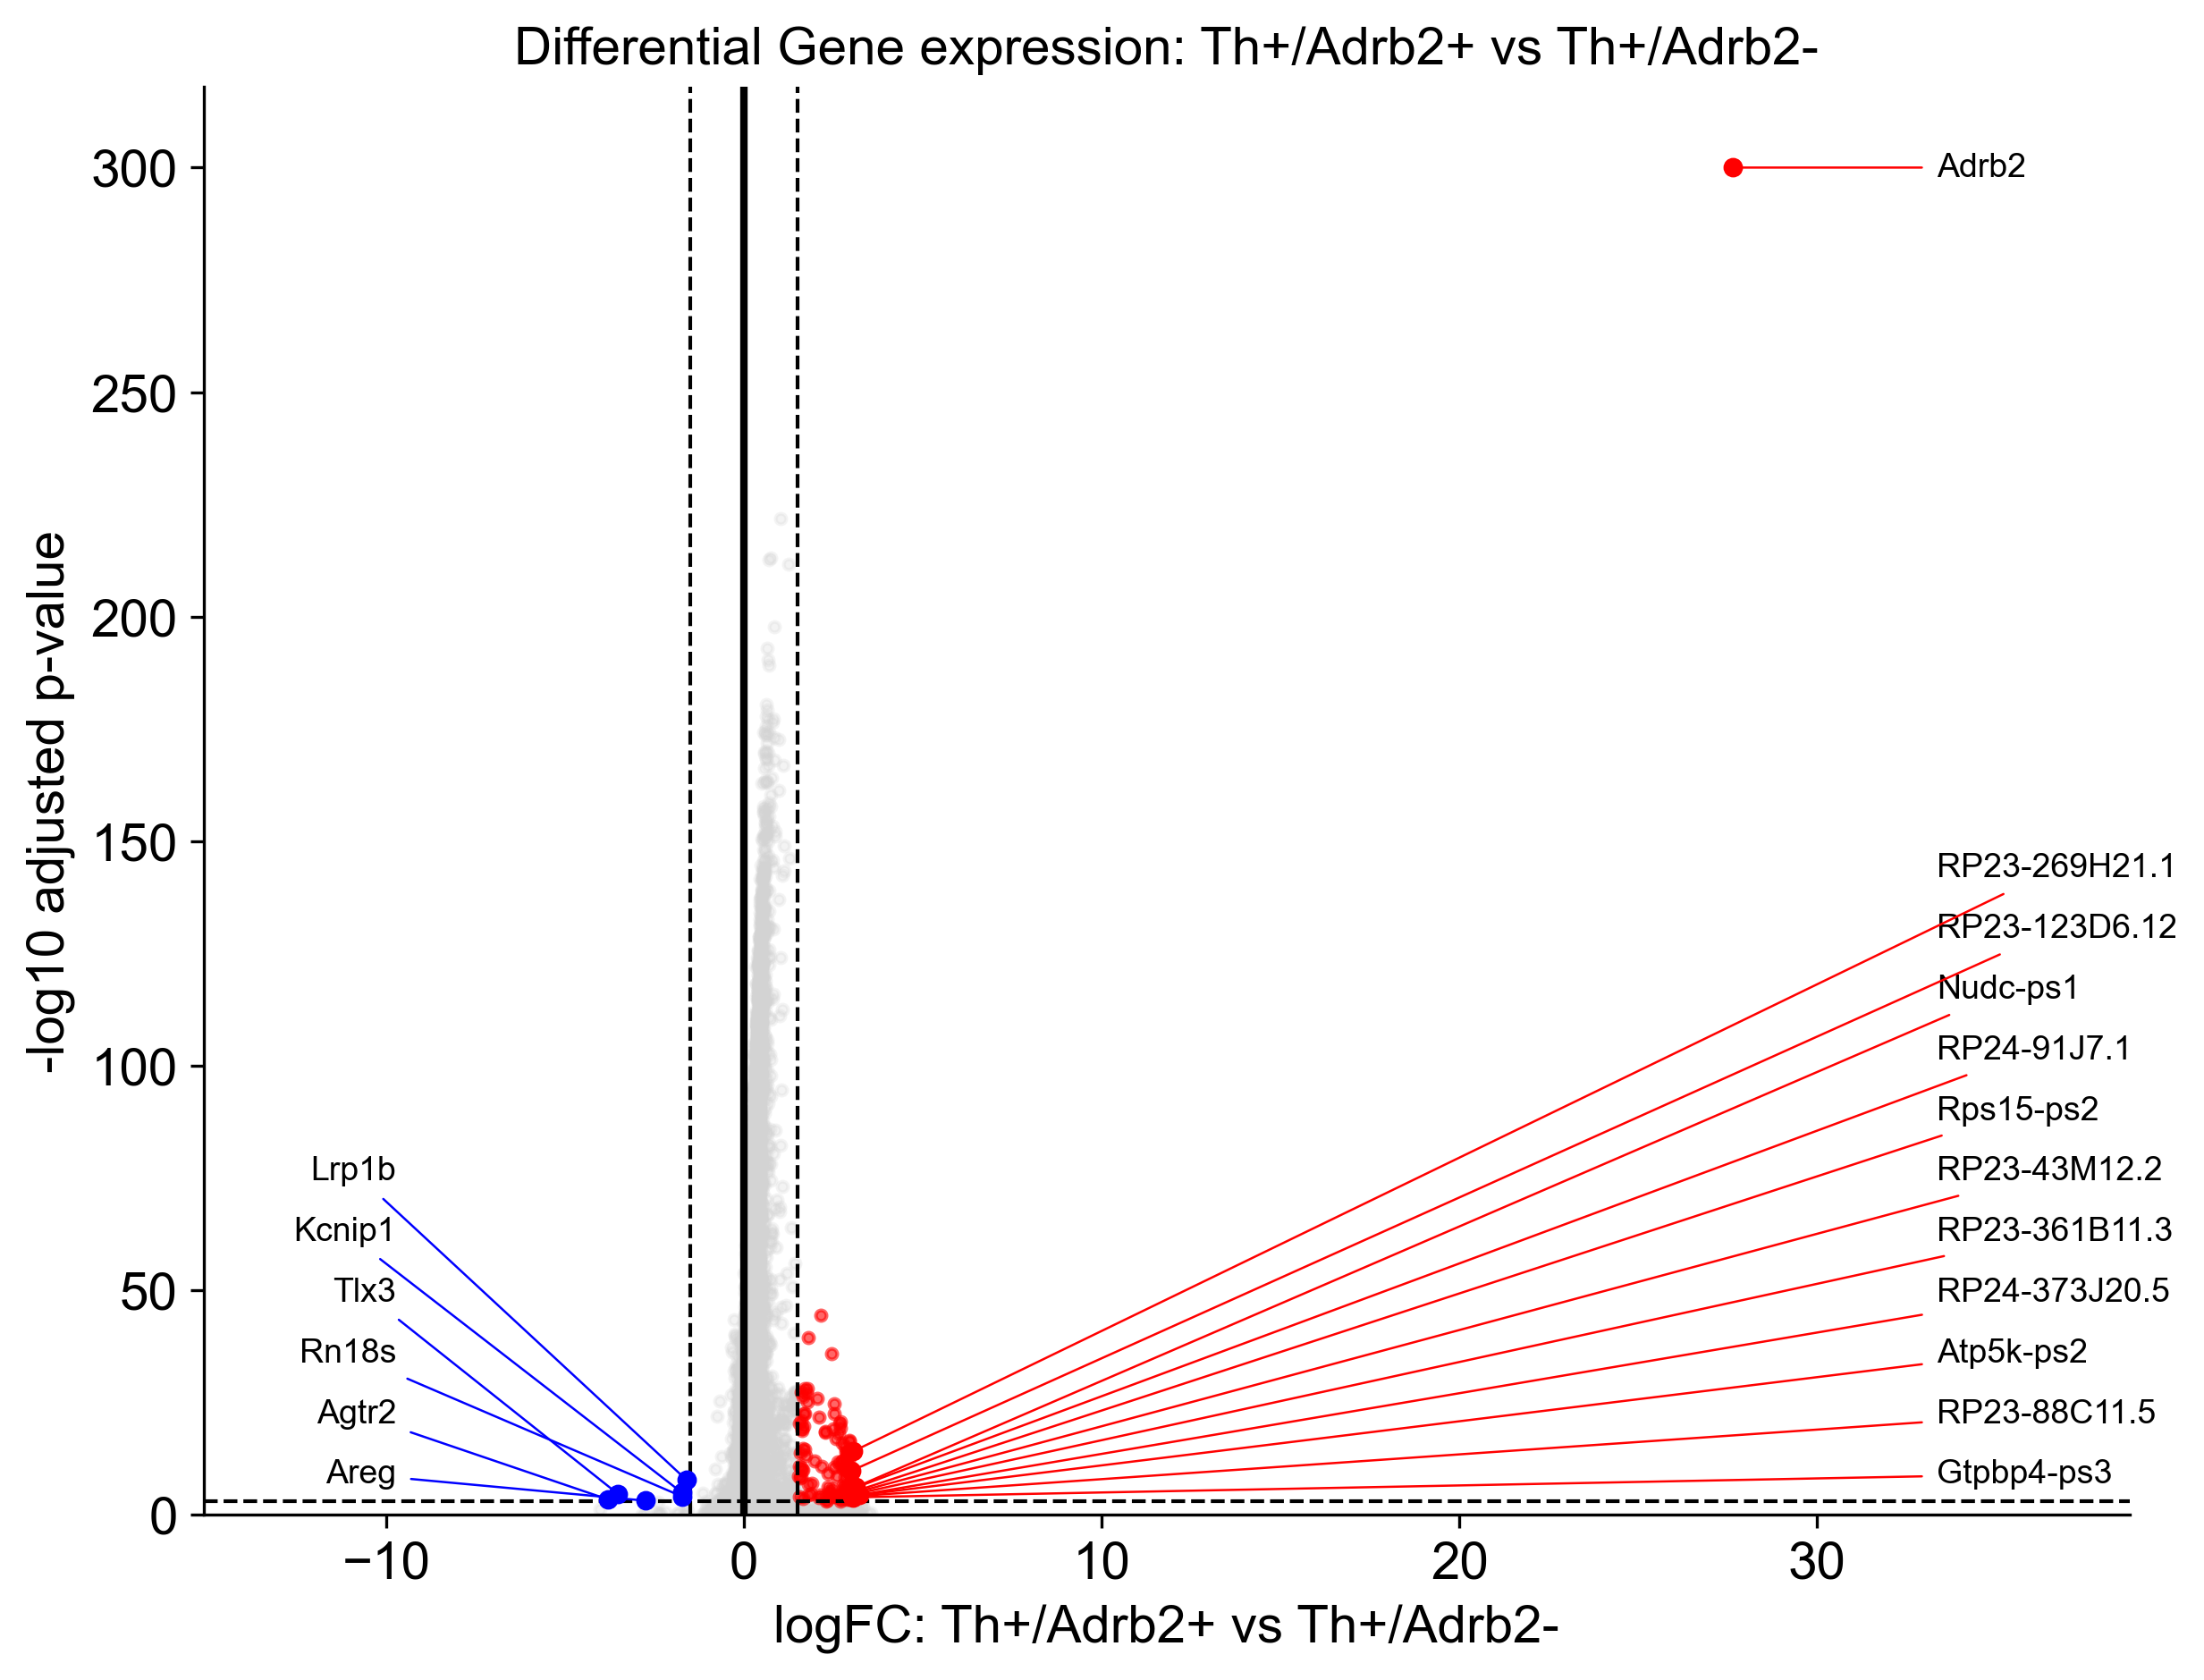

In [39]:
padj_thr = 3
fc_thr = 1.5

force_up_labels = ["Cdh12", "Auts2l1", "Cntnap5c", "Akap2", "Pcdhac2", "Samd5", "Chsy3", "Supt3h"]

top_up = df[(df["logfoldchanges"] > fc_thr) & (df["neglog10_padj"] >= padj_thr)].nlargest(n_label, "logfoldchanges")
top_dn = df[(df["logfoldchanges"] < -fc_thr) & (df["neglog10_padj"] >= padj_thr)].nsmallest(n_label, "logfoldchanges")

force_up = df[
    df["names"].isin(force_up_labels)
].copy()

lab = pd.concat([top_up, top_dn], axis=0).drop_duplicates("names")

fig, ax = plt.subplots(figsize=(8.5, 6.5))

x = df["logfoldchanges"].to_numpy()
y = df["neglog10_padj"].to_numpy()

m_up = (x > fc_thr) & (y >= padj_thr)
m_dn = (x < -fc_thr) & (y >= padj_thr)
m_mid = ~(m_up | m_dn)

ax.scatter(x[m_mid], y[m_mid], s=8, alpha=0.25, c="lightgray")
ax.scatter(x[m_up], y[m_up], s=8, alpha=0.6, c="red")
ax.scatter(x[m_dn], y[m_dn], s=8, alpha=0.6, c="blue")

lab2 = lab.copy()
lab2["logfoldchanges"] = pd.to_numeric(lab2["logfoldchanges"], errors="coerce")
lab2["neglog10_padj"] = pd.to_numeric(lab2["neglog10_padj"], errors="coerce")
lab2 = lab2[
    np.isfinite(lab2["logfoldchanges"]) &
    np.isfinite(lab2["neglog10_padj"]) &
    (lab2["neglog10_padj"] >= padj_thr) &
    ((lab2["logfoldchanges"] > fc_thr) | (lab2["logfoldchanges"] < -fc_thr))
].copy()

x_min, x_max = np.nanmin(x), np.nanmax(x)
y_min, y_max = 0.0, np.nanmax(y)
x_span = x_max - x_min
y_span = y_max - y_min if y_max > y_min else 1.0

ax.set_xlim(x_min - 0.35 * x_span, x_max + 0.35 * x_span)
ax.set_ylim(y_min, y_max + 0.06 * y_span)

x_left = x_min - 0.18 * x_span
x_right = x_max + 0.18 * x_span
min_dy = 0.045 * y_span

def spread_positions(vals, low, high, min_dy):
    vals = np.asarray(vals, dtype=float).copy()
    if vals.size == 0:
        return vals
    vals.sort()
    out = vals.copy()
    out[0] = max(out[0], low)
    for i in range(1, len(out)):
        out[i] = max(out[i], out[i - 1] + min_dy)
    overflow = out[-1] - high
    if overflow > 0:
        out -= overflow
        if out[0] < low:
            out = np.linspace(low, high, len(out))
    return out

left = lab2[lab2["logfoldchanges"] < -fc_thr].sort_values("neglog10_padj").copy()
right = lab2[lab2["logfoldchanges"] > fc_thr].sort_values("neglog10_padj").copy()

left_y = spread_positions(left["neglog10_padj"].to_numpy(), max(padj_thr, y_min + 0.03 * y_span), y_max, min_dy)
right_y = spread_positions(right["neglog10_padj"].to_numpy(), max(padj_thr, y_min + 0.03 * y_span), y_max, min_dy)

for (_, r), y_txt in zip(left.iterrows(), left_y):
    xr = float(r["logfoldchanges"])
    yr = float(r["neglog10_padj"])
    ax.scatter([xr], [yr], s=18, c="blue", zorder=3)
    ax.annotate(
        str(r["names"]),
        xy=(xr, yr),
        xytext=(x_left, y_txt),
        ha="right",
        va="center",
        fontsize=9,
        arrowprops=dict(arrowstyle="-", lw=0.6, color="blue", shrinkA=2, shrinkB=2),
    )

for (_, r), y_txt in zip(right.iterrows(), right_y):
    xr = float(r["logfoldchanges"])
    yr = float(r["neglog10_padj"])
    ax.scatter([xr], [yr], s=18, c="red", zorder=3)
    ax.annotate(
        str(r["names"]),
        xy=(xr, yr),
        xytext=(x_right, y_txt),
        ha="left",
        va="center",
        fontsize=9,
        arrowprops=dict(arrowstyle="-", lw=0.6, color="red", shrinkA=2, shrinkB=2),
    )

ax.axvline(-fc_thr, color="k", lw=1, ls="--")
ax.axvline(0, color="k", lw=2)
ax.axvline(fc_thr, color="k", lw=1, ls="--")
ax.axhline(padj_thr, color="k", lw=1, ls="--")
ax.set_xlabel(f"logFC: {group_pos} vs {group_neg}")
ax.set_ylabel("-log10 adjusted p-value")
ax.set_title(f"Differential Gene expression: {group_pos} vs {group_neg}")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


In [19]:
top_up

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,neglog10_padj
0,Adrb2,95.802162,27.643784,0.000000e+00,0.000000e+00,1.000000,300.000000
10417,Nudc-ps1,5.426909,3.117507,5.733831e-08,6.986351e-07,0.064332,6.155750
10963,Atp5k-ps2,4.544713,3.077001,5.501011e-06,6.366570e-05,0.054085,4.196094
11081,Gtpbp4-ps3,4.384172,3.056178,1.164274e-05,1.333134e-04,0.052092,3.875126
10697,Pcna-ps2,4.923873,2.997958,8.484787e-07,1.006817e-05,0.058924,4.997050
8794,AV026068,8.089560,2.991961,5.988102e-16,8.651545e-15,0.097068,14.062906
9884,Psmb6-ps2,6.280486,2.989855,3.375172e-10,4.335131e-09,0.075149,8.362998
9688,Trmt112-ps2,6.594650,2.968199,4.262588e-11,5.588131e-10,0.079704,9.252733
10192,Tdpx-ps1,5.747306,2.945196,9.067626e-09,1.129112e-07,0.069456,6.947263
8370,Vdac3-ps1,8.761196,2.944185,1.931901e-18,2.933810e-17,0.106746,16.532568


In [113]:
top_dn

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,neglog10_padj
127959,Cbln2,-2.741702,-4.027028,6.112182e-03,6.204453e-02,0.006547,1.207297
127987,Agtr2,-4.152988,-3.811386,3.281619e-05,3.704256e-04,0.011956,3.431299
127995,Tlx3,-4.773411,-3.534034,1.811316e-06,2.128043e-05,0.011386,4.672020
127937,Dach1,-1.689345,-2.865035,9.115335e-02,8.202123e-01,0.014233,0.086074
127981,Areg,-3.994272,-2.767589,6.489346e-05,7.263021e-04,0.048961,3.138883
127942,Bcl11a,-1.858973,-2.744230,6.303097e-02,5.809852e-01,0.011956,0.235835
127949,Asic4,-2.007738,-2.430277,4.467117e-02,4.187146e-01,0.018787,0.378082
127938,Slc38a4,-1.773210,-2.399728,7.619389e-02,6.940238e-01,0.021065,0.158626
127977,Ppp1r1c,-3.761666,-2.398727,1.687855e-04,1.859355e-03,0.045545,2.730638
127944,Igfbpl1,-1.909831,-2.352281,5.615499e-02,5.207162e-01,0.017079,0.283399


# Coexpression analysis

In [48]:
import re
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

plt.rcParams["font.family"] = "Arial"

def _get_1d_expr(adata, gene):
    x = adata[:, gene].X
    if sp.issparse(x):
        return x.toarray().ravel()
    return np.asarray(x).ravel()

def _gene_label(g):
    g = str(g)
    if g.isupper():
        g = g[:1] + g[1:].lower()
    return g

def _italic(s):
    # mathtext italic
    return r"$\it{" + re.sub(r"([{}\\])", r"\\\1", str(s)) + r"}$"

def calculate_coexpression_percentage(adata, gene1, gene2, threshold=0.5):
    g1 = _get_1d_expr(adata, gene1)
    g2 = _get_1d_expr(adata, gene2)
    gene1_expressed = g1 > threshold
    coexpression_cells = (g1 > threshold) & (g2 > threshold)
    # get percentage of cells coexpressing both in relation to all cells
    total_cells = g1.shape[0]
    coexpression_percentage = (coexpression_cells.sum() / total_cells) * 100
    return coexpression_percentage

def plot_coexpression_percentage(
    adata,
    gene1,
    gene2,
    threshold=0.5,
    ax=None,
    *,
    axis_label_fontsize=16,
    tick_labelsize=12,
    legend_fontsize=11,
):
    coexpression_percentage = calculate_coexpression_percentage(adata, gene1, gene2, threshold)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure

    g1 = _get_1d_expr(adata, gene1)
    g2 = _get_1d_expr(adata, gene2)
    gene1_expressed = g1 > threshold
    gene2_expressed = g2 > threshold

    cats = []
    for x, y in zip(gene1_expressed, gene2_expressed):
        if x and y:
            cats.append("Co-expression")
        elif x or y:
            cats.append("Single Gene Expression")
        else:
            cats.append("No Expression")
    adata.obs["coexpression"] = pd.Categorical(cats)

    cmap = {
        "Co-expression": "#ad0303",
        "No Expression": "grey",
        "Single Gene Expression": "#0350ad",
    }
    cat_order = list(adata.obs["coexpression"].cat.categories)
    palette = [cmap[c] for c in cat_order]

    g1_lab = _italic(_gene_label(gene1))
    g2_lab = _italic(_gene_label(gene2))

    sc.pl.scatter(
        adata,
        x=gene1,
        y=gene2,
        color="coexpression",
        use_raw=False,
        size=15,
        title=f"Co-expression of {g1_lab} and {g2_lab}",
        ax=ax,
        palette=palette,
        show=False,
    )

    ax.title.set_fontname("Arial")
    ax.title.set_fontsize(axis_label_fontsize)

    g1_lab = _italic(_gene_label(gene1))
    g2_lab = _italic(_gene_label(gene2))

    ax.set_xlabel(f"{g1_lab} expression", fontsize=axis_label_fontsize, fontname="Arial")
    ax.set_ylabel(f"{g2_lab} expression", fontsize=axis_label_fontsize, fontname="Arial")
    ax.tick_params(axis="both", labelsize=tick_labelsize)
    for tl in ax.get_xticklabels() + ax.get_yticklabels():
        tl.set_fontname("Arial")

    gene1_expression_percentage = float(gene1_expressed.mean()) * 100
    gene2_expression_percentage = float(gene2_expressed.mean()) * 100

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#0350ad", markersize=10, 
                   label=f"{g1_lab}+ ({gene1_expression_percentage:.2f}%)"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#0350ad", markersize=10,
                   label=f"{g2_lab}+ ({gene2_expression_percentage:.2f}%)"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#ad0303", markersize=10,
                   label=f"Double-positive ({coexpression_percentage:.2f}%)")
    ]
    leg = ax.legend(handles=handles, loc="best", title="")
    if leg is not None:
        if leg.get_title() is not None:
            leg.get_title().set_fontname("Arial")
            leg.get_title().set_fontsize(legend_fontsize)
        for t in leg.get_texts():
            t.set_fontname("Arial")
            t.set_fontsize(legend_fontsize)

    ax.grid(False)
    return fig, ax


(<Figure size 750x750 with 1 Axes>,
 <Axes: title={'center': 'Co-expression of $\\it{Th}$ and $\\it{Adrb2}$'}, xlabel='$\\it{Th}$ expression', ylabel='$\\it{Adrb2}$ expression'>)

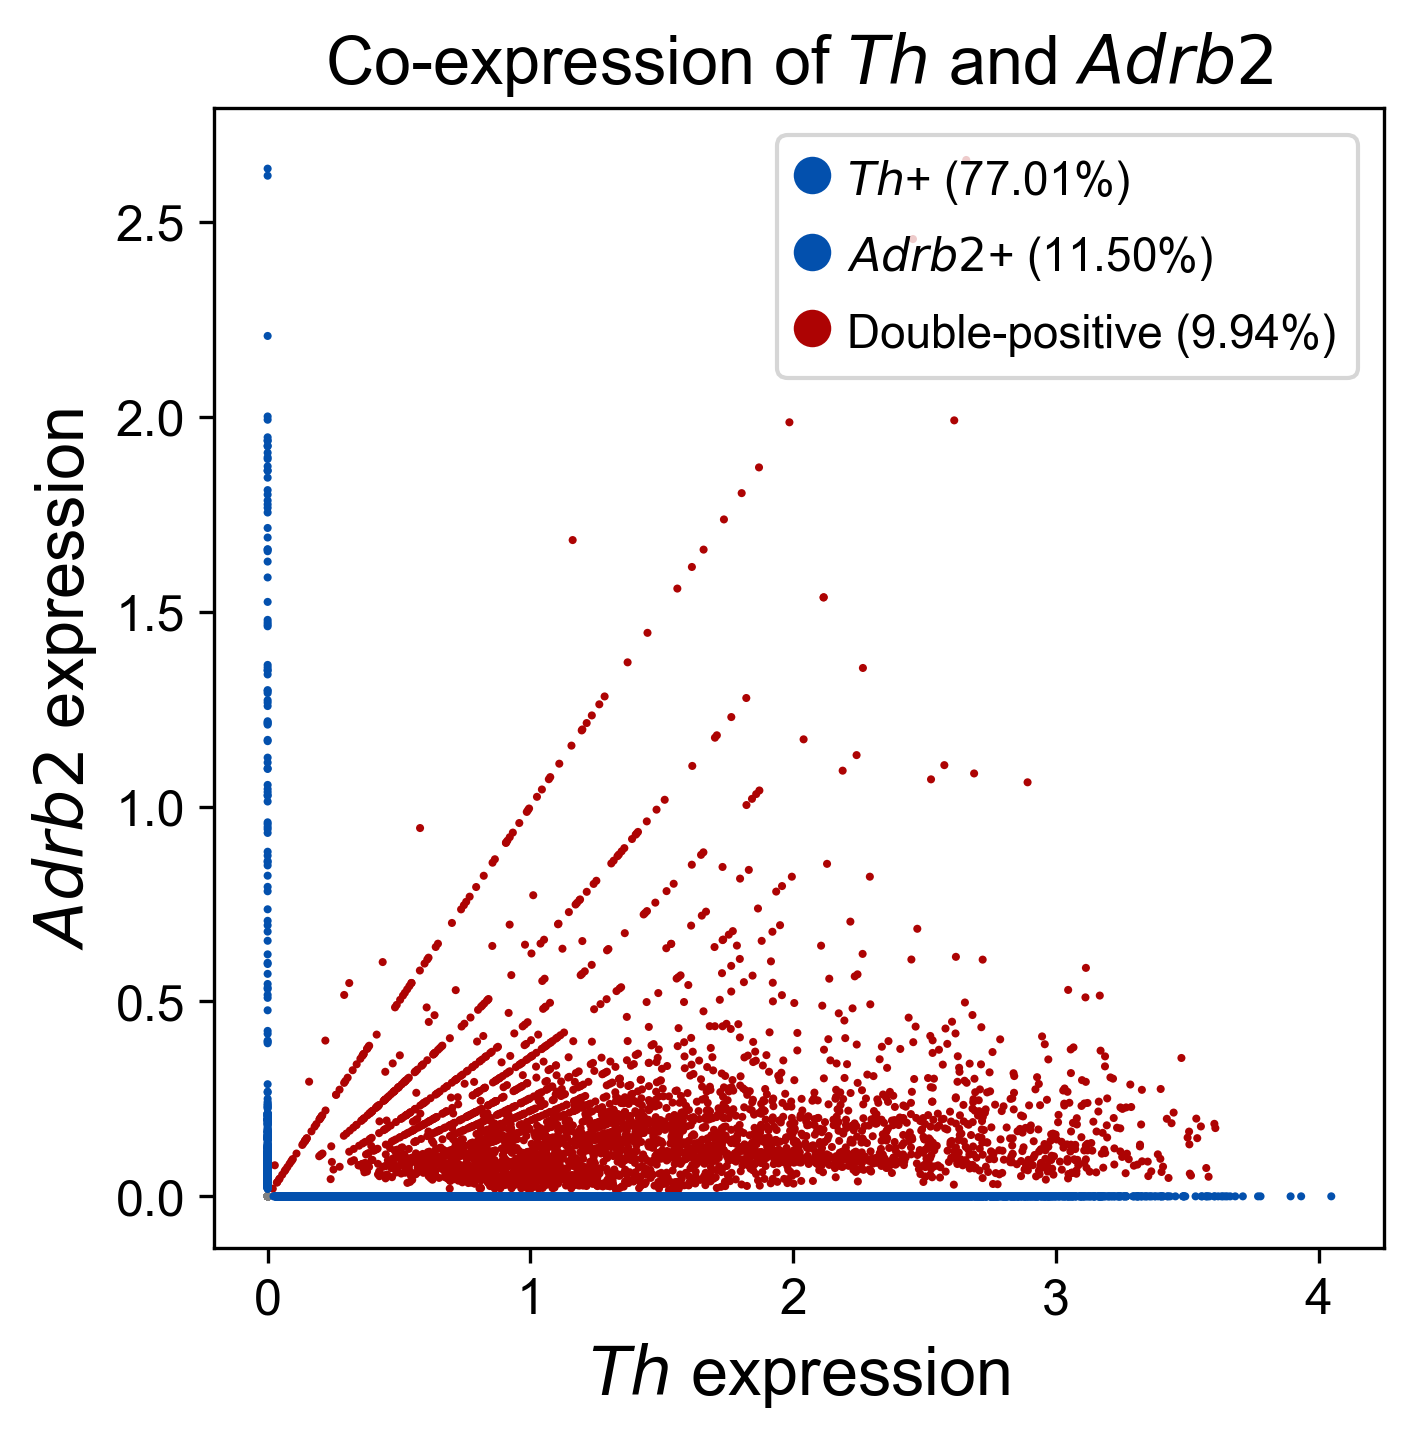

In [54]:
plot_coexpression_percentage(adata.raw.to_adata(), 'Th', 'Adrb2', threshold=0)

(<Figure size 750x750 with 1 Axes>,
 <Axes: title={'center': 'Co-expression of $\\it{Adrb2}$ and $\\it{Cdh12}$'}, xlabel='$\\it{Adrb2}$ expression', ylabel='$\\it{Cdh12}$ expression'>)

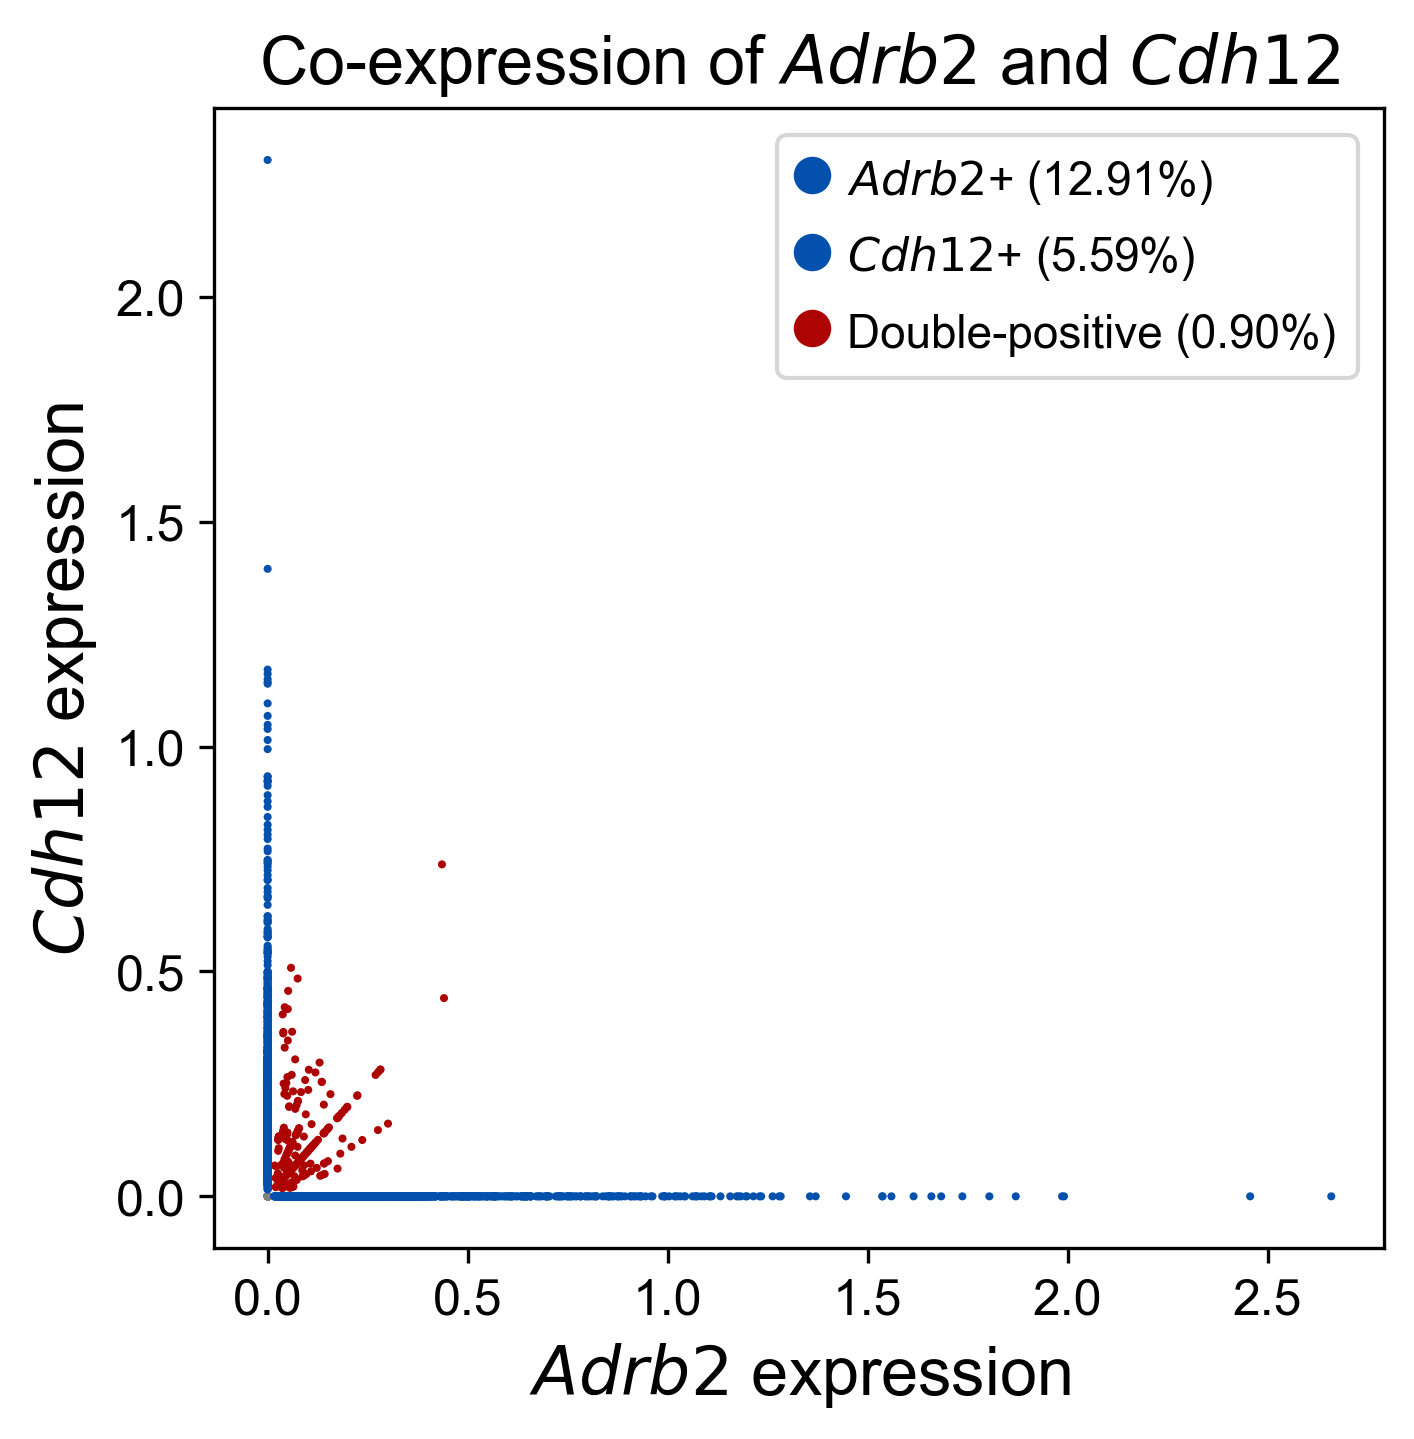

In [53]:
# subset adata to "Th+ cells"
th_pos = _get_1d_expr(adata.raw.to_adata(), 'Th') > 0
adata_th_pos = adata[th_pos].copy()

plot_coexpression_percentage(adata_th_pos.raw.to_adata(), 'Adrb2', 'Cdh12', threshold=0)

In [61]:
# calculate and plot Spearman rho correlation between Adrb2 and Cdh12 in Th+ cells, using only expression values above 0 (i.e. only in cells expressing both genes)
from scipy.stats import spearmanr
def calculate_spearman_correlation(adata, gene1, gene2):
    g1 = _get_1d_expr(adata, gene1)
    g2 = _get_1d_expr(adata, gene2)
    # filter out cells with 0 expression for either gene
    mask = (g1 > 0) & (g2 > 0)
    g1 = g1[mask]
    g2 = g2[mask]
    rho, pval = spearmanr(g1, g2)
    return rho, pval


# plot scatter plot of Adrb2 vs Cdh12 expression in Th+ cells, with a regression line and the Spearman rho value in the title
def plot_gene_correlation(adata, gene1, gene2, ax=None):
    g1 = _get_1d_expr(adata, gene1)
    g2 = _get_1d_expr(adata, gene2)
    mask = (g1 > 0) & (g2 > 0)
    g1 = g1[mask]
    g2 = g2[mask]
    rho, pval = spearmanr(g1, g2)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure

    ax.scatter(g1, g2, s=15, alpha=0.6)
    m, b = np.polyfit(g1, g2, 1)
    x_fit = np.array([g1.min(), g1.max()])
    y_fit = m * x_fit + b
    ax.plot(x_fit, y_fit, color="red", lw=2, ls="--")

    g1_lab = _italic(_gene_label(gene1))
    g2_lab = _italic(_gene_label(gene2))
    ax.grid(False)
    ax.set_xlabel(f"{g1_lab} expression", fontsize=14, fontname="Arial")
    ax.set_ylabel(f"{g2_lab} expression", fontsize=14, fontname="Arial")
    ax.set_title(f"Spearman rho={rho:.4f}, p={pval:.4e}", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    for tl in ax.get_xticklabels() + ax.get_yticklabels():
        tl.set_fontname("Arial")

    return fig, ax

Spearman correlation between Adrb2 and Cdh12 in Th+ cells: rho=0.4190, p-value=7.0879e-12


(<Figure size 750x750 with 1 Axes>,
 <Axes: title={'center': 'Spearman rho=0.4190, p=7.0879e-12'}, xlabel='$\\it{Adrb2}$ expression', ylabel='$\\it{Cdh12}$ expression'>)

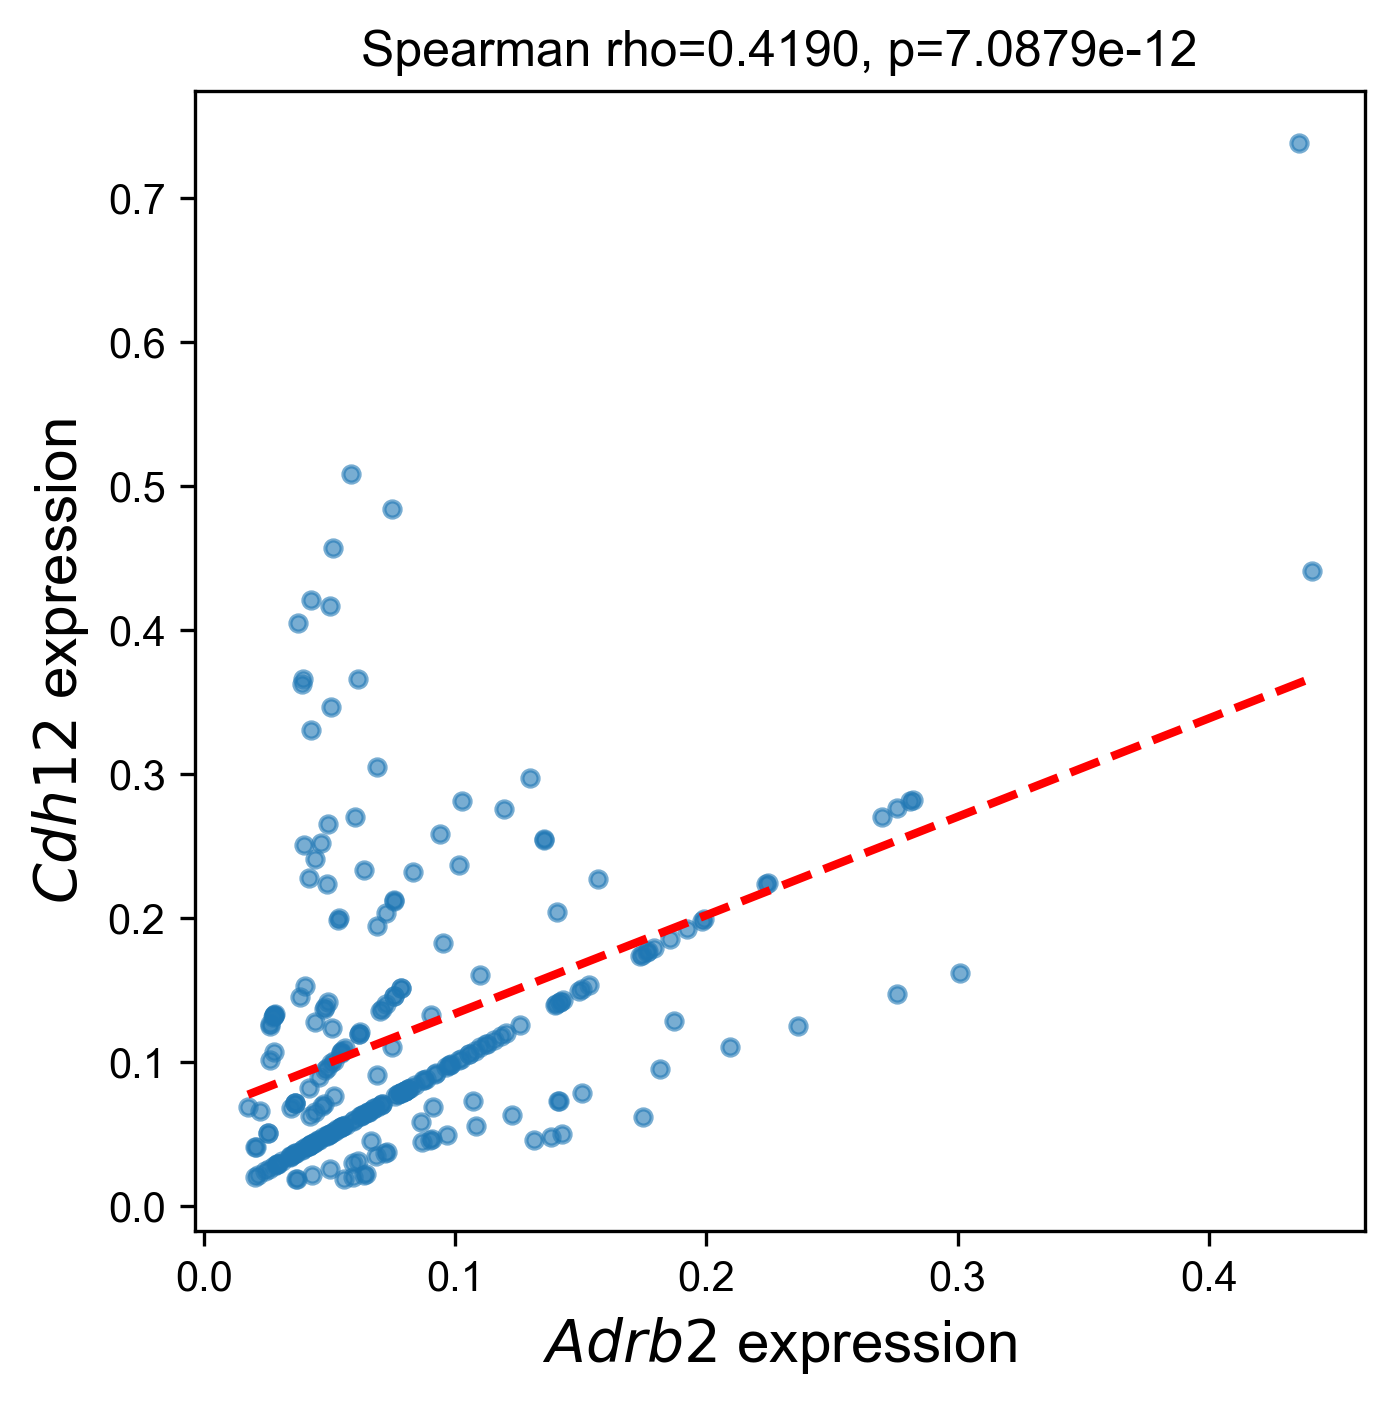

In [64]:
rho, pval = calculate_spearman_correlation(adata_th_pos.raw.to_adata(), 'Adrb2', 'Cdh12')
print(f"Spearman correlation between Adrb2 and Cdh12 in Th+ cells: rho={rho:.4f}, p-value={pval:.4e}")


plot_gene_correlation(adata_th_pos.raw.to_adata(), 'Adrb2', 'Cdh12')

In [ ]:
# calculate percentage of cells expressing TH

adata_raw = adata.raw.to_adata()
adata_raw.X = adata_raw.X.toarray() if sp.issparse(adata_raw.X) else adata_raw.X

th_expression_percentage = (adata_raw[:, 'TH'].X > 0).mean() * 100
adrb2_expression_percentage = (adata_raw[:, 'ADRB2'].X > 0).mean() * 100
double_positive_percentage = ((adata_raw[:, 'TH'].X > 0) & (adata_raw[:, 'ADRB2'].X > 0)).mean() * 100
print(f"Percentage of cells expressing TH: {th_expression_percentage:.2f}%")
print(f"Percentage of cells expressing ADRB2: {adrb2_expression_percentage:.2f}%")
print(f"Percentage of cells co-expressing TH and ADRB2: {double_positive_percentage:.2f}%")

In [ ]:
# calculate number of cells expressing TH

th_expressing_cells = (adata_raw[:, 'TH'].X > 0).sum()
adrb2_expressing_cells = (adata_raw[:, 'ADRB2'].X > 0).sum()
double_positive_cells = ((adata_raw[:, 'TH'].X > 0) & (adata_raw[:, 'ADRB2'].X > 0)).sum()

print(f"Number of cells expressing TH: {th_expressing_cells}")
print(f"Number of cells expressing ADRB2: {adrb2_expressing_cells}")
print(f"Number of cells co-expressing TH and ADRB2: {double_positive_cells}")

(<Figure size 750x750 with 1 Axes>,
 <Axes: title={'center': 'Co-expression of TH and ADRB2'}, xlabel='TH', ylabel='ADRB2'>)

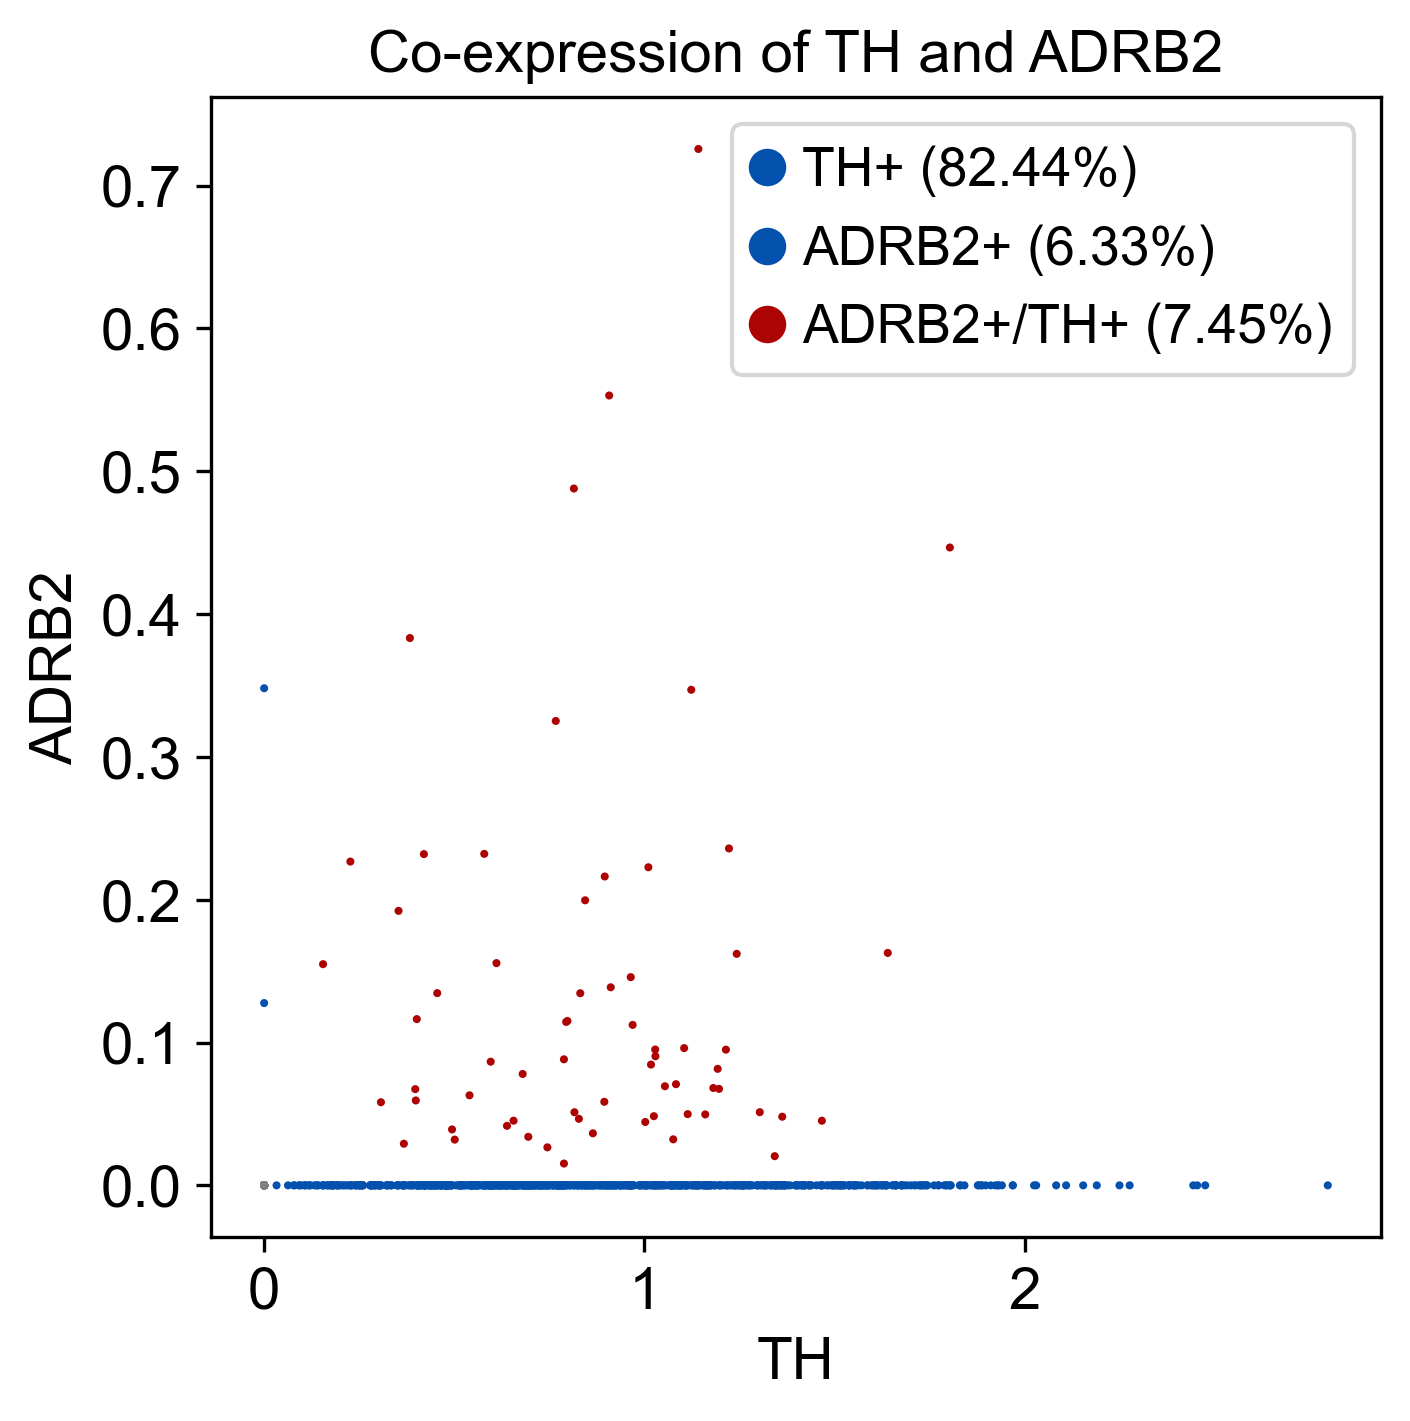

In [22]:
human = adata[adata.obs['Species']=='Human', :]
plot_coexpression_percentage(human.raw.to_adata(), 'TH', 'ADRB2', threshold=0)

(<Figure size 750x750 with 1 Axes>,
 <Axes: title={'center': 'Co-expression of TH and ADRB2'}, xlabel='TH', ylabel='ADRB2'>)

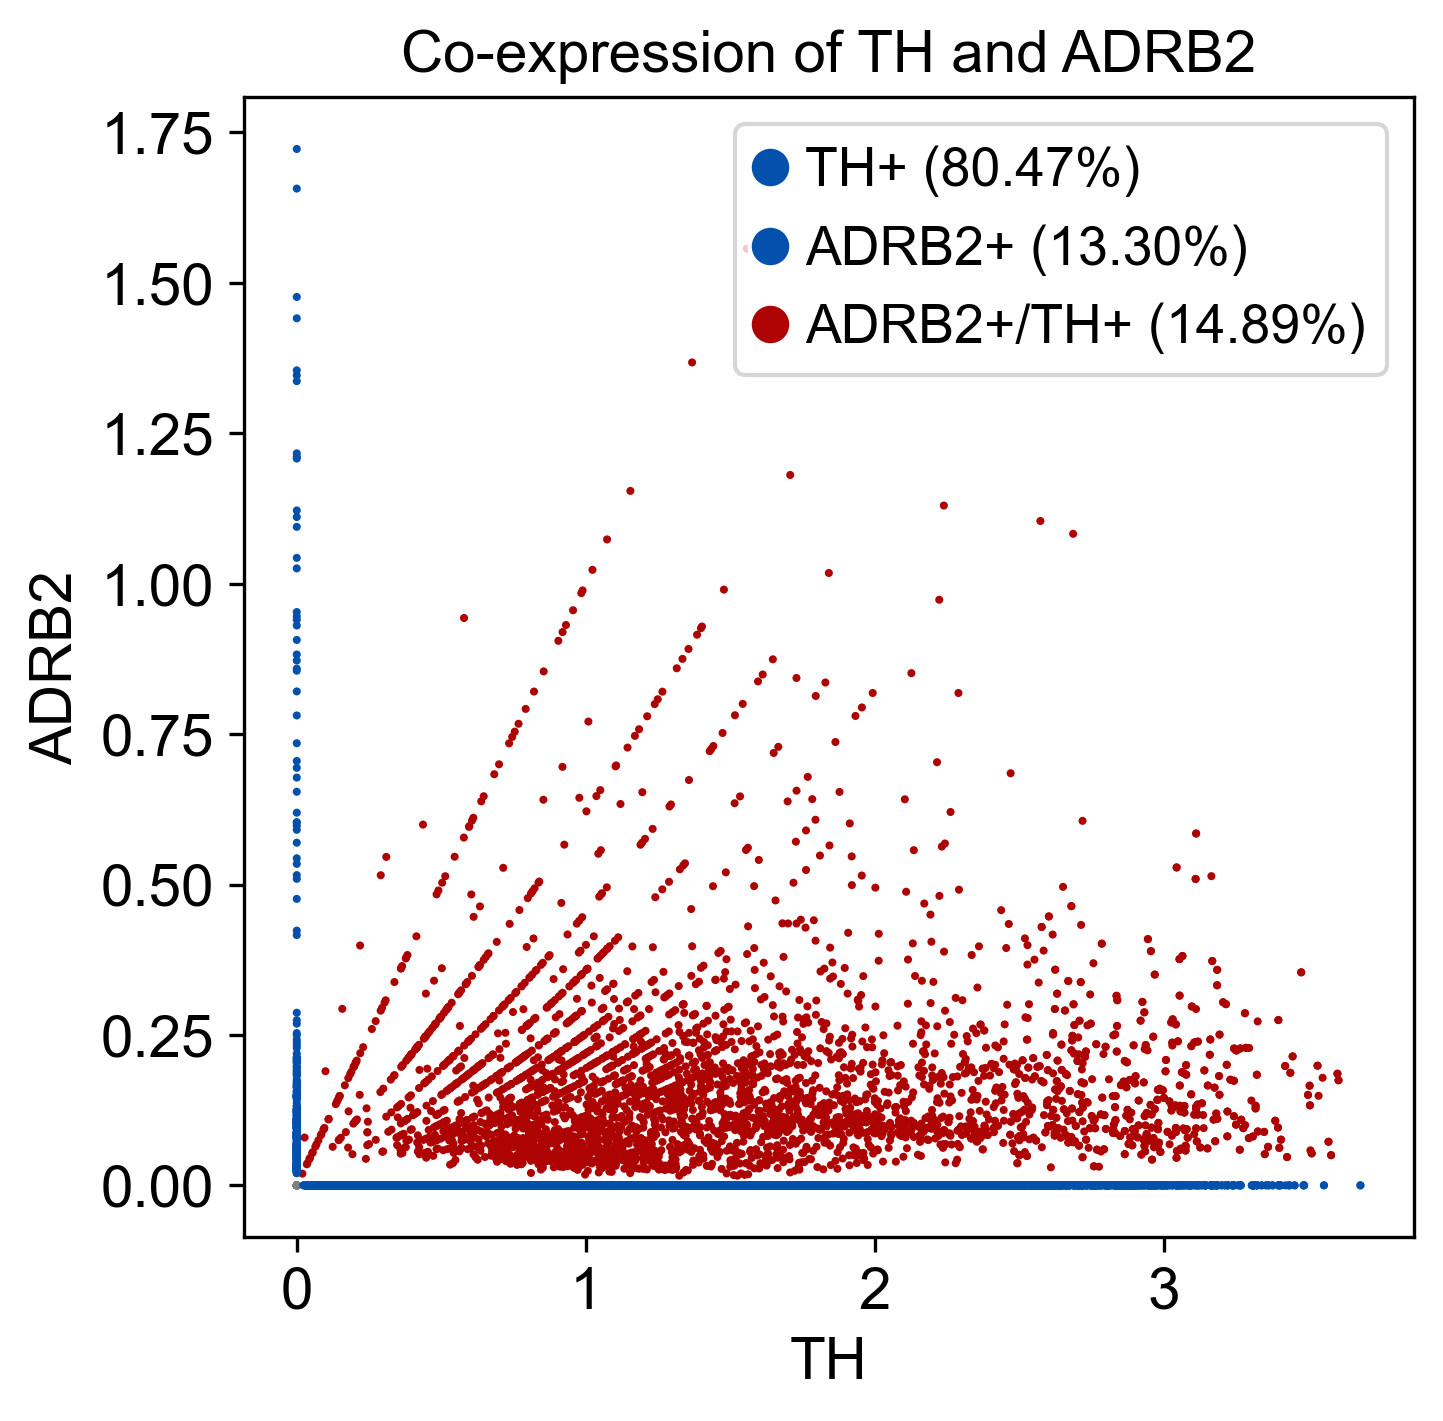

In [23]:
mouse = adata[adata.obs['Species']=='Mouse', :]
plot_coexpression_percentage(mouse.raw.to_adata(), 'TH', 'ADRB2', threshold=0)